# Layout & Mosaic Generation

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Circle
import windIO
import xarray as xr
from pyproj import Transformer
from scipy import ndimage
from scipy.spatial import cKDTree
from shapely.geometry import shape
from shapely.ops import unary_union, transform as shp_transform
from shapely.vectorized import contains as shapely_contains

sys.path.insert(0, str(Path("..") / "Monte_Carlo_v3"))
import mosaic
import tiling
import settings
import cluster
import timeline
import turbines
import spacing

DATA_DIR = settings.DATA_DIR
SLA_PATH = DATA_DIR.parent / "WindFarms" / "US_Cluster" / "Data" / "Federal_State_Boundary_SLA.geojson"
STATES_PATH = DATA_DIR.parent / "Create_Graphs" / "data" / "us_states.json"
ETOPO_PATH = DATA_DIR.parent / "Create_Graphs" / "data" / "etopo_east_coast_hires.nc"

FIXED_BOTTOM_MAX_DEPTH = 80.0
BATHY_SMOOTH_M = 2_000.0
RESOLUTION_M = 300.0
RADIUS_KM = 150.0
BUFFER_CELLS = 3
CLUSTER_BUFFER_M = 1_000.0
FRAGMENT_AREA_KM2 = 30.0
SEED = 9

COLOR_LAND = "#ece9e2"
COLOR_LEASE = "#2b2a27"
MAP_FIGSIZE = (8, 8)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

wind_farm_us = windIO.load_yaml(DATA_DIR / "wind_farm_us.yaml")
vineyard = next(f for f in wind_farm_us if f["name"] == "Vineyard Wind")
vineyard_center = np.array([
    np.mean(vineyard["layouts"][0]["coordinates"]["x"]),
    np.mean(vineyard["layouts"][0]["coordinates"]["y"]),
])

etopo = xr.open_dataset(ETOPO_PATH)
etopo_lon = etopo["longitude"].values
etopo_lat = etopo["latitude"].values
etopo_z = etopo["z"].values

to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32619", always_xy=True)
to_lonlat = Transformer.from_crs("EPSG:32619", "EPSG:4326", always_xy=True)

sla_raw = json.load(open(SLA_PATH))["features"][0]["geometry"]["coordinates"]
lon_min, lon_max, lat_min, lat_max = -73.0, -68.5, 40.0, 43.0
sla_lines_utm = []
for line in sla_raw:
    pts = np.array(line)
    keep = (pts[:, 0] >= lon_min) & (pts[:, 0] <= lon_max) & (pts[:, 1] >= lat_min) & (pts[:, 1] <= lat_max)
    if keep.sum() < 2:
        continue
    sub = pts[keep]
    x, y = to_utm.transform(sub[:, 0], sub[:, 1])
    sla_lines_utm.append(np.column_stack([x, y]))
sla_all = np.vstack(sla_lines_utm)
tangents = np.zeros_like(sla_all)
offset = 0
for line in sla_lines_utm:
    n = len(line)
    tangents[offset:offset + n] = np.gradient(line, axis=0)
    offset += n
sla_tree = cKDTree(sla_all)

def sla_side(xs, ys):
    pts = np.column_stack([xs, ys])
    _, idx = sla_tree.query(pts)
    vec = pts - sla_all[idx]
    cross = tangents[idx, 0] * vec[:, 1] - tangents[idx, 1] * vec[:, 0]
    return np.sign(cross)

federal_sign = np.sign(sla_side(np.array([vineyard_center[0]]), np.array([vineyard_center[1]])).mean())

R = RADIUS_KM * 1000
margin = 5_000.0
all_x = np.concatenate([np.array(p.exterior.coords.xy[0]) for p in cluster.LEASE_TEMPLATES.values()])
all_y = np.concatenate([np.array(p.exterior.coords.xy[1]) for p in cluster.LEASE_TEMPLATES.values()])
x0 = min(vineyard_center[0] - R - margin, all_x.min() - margin)
x1 = max(vineyard_center[0] + R + margin, all_x.max() + margin)
y0 = min(vineyard_center[1] - R - margin, all_y.min() - margin)
y1 = max(vineyard_center[1] + R + margin, all_y.max() + margin)
nx = int((x1 - x0) / RESOLUTION_M) + 1
ny = int((y1 - y0) / RESOLUTION_M) + 1
gx = x0 + np.arange(nx) * RESOLUTION_M
gy = y0 + np.arange(ny) * RESOLUTION_M
GX, GY = np.meshgrid(gx, gy, indexing="xy")
GXf, GYf = GX.ravel(), GY.ravel()
EXTENT_KM = [x0 / 1000, x1 / 1000, y0 / 1000, y1 / 1000]

states_raw = json.load(open(STATES_PATH))
near_states = {"Massachusetts", "Rhode Island", "Connecticut", "New York", "New Jersey", "New Hampshire", "Maine", "Vermont"}
land_polygons = []
for feat in states_raw["features"]:
    if feat["properties"]["name"] in near_states:
        g = shape(feat["geometry"])
        land_polygons.append(shp_transform(to_utm.transform, g))

def new_ax(figsize=MAP_FIGSIZE):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    return fig, ax

def draw_land(ax):
    for geom in land_polygons:
        parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
        for part in parts:
            bx, by = part.exterior.xy
            ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color=COLOR_LAND, alpha=0.6, zorder=0, linewidth=0)

def draw_cluster_outline(ax, lw=0.8):
    outline = unary_union(list(cluster.LEASE_TEMPLATES.values()))
    parts = outline.geoms if outline.geom_type == "MultiPolygon" else [outline]
    for part in parts:
        bx, by = part.exterior.xy
        ax.plot(np.array(bx) / 1000, np.array(by) / 1000, color=COLOR_LEASE, linewidth=lw, alpha=0.8)

/opt/anaconda3/envs/wesl_jul_31/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Base Data: Map, Bathymetry & Boundaries

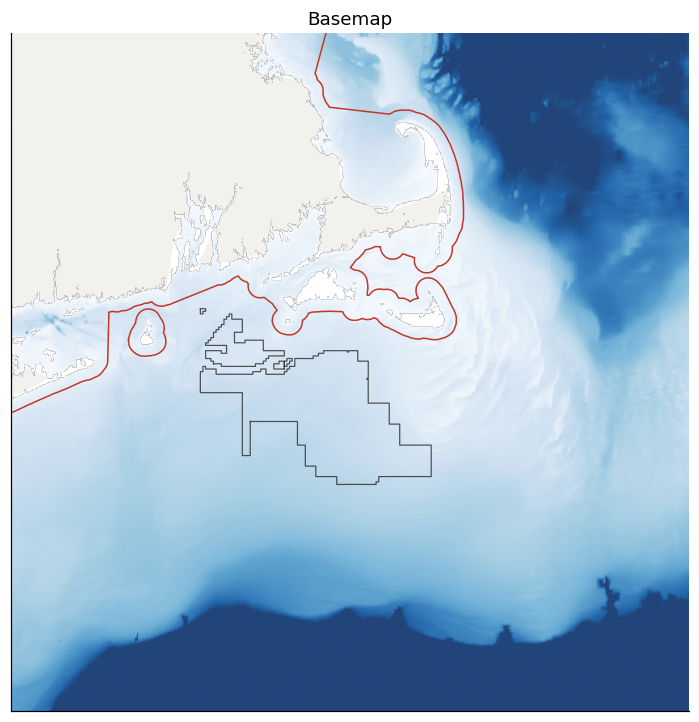

In [2]:
LON, LAT = to_lonlat.transform(GX, GY)
lon_idx = np.clip(np.searchsorted(etopo_lon, LON), 0, len(etopo_lon) - 1)
lat_idx = np.clip(np.searchsorted(etopo_lat, LAT), 0, len(etopo_lat) - 1)
z_grid = etopo_z[lat_idx, lon_idx]
depth_grid = -z_grid
on_land = z_grid >= 0
depth_grid_masked = np.ma.masked_where(on_land, depth_grid)

fig, ax = new_ax()
ax.set_xlim(EXTENT_KM[0], EXTENT_KM[1]); ax.set_ylim(EXTENT_KM[2], EXTENT_KM[3])
draw_land(ax)
ax.imshow(depth_grid_masked, origin="lower", extent=EXTENT_KM, cmap="Blues", vmax=200, alpha=0.9, zorder=1)
for line in sla_lines_utm:
    ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="#c0392b", linewidth=1.0, zorder=2)
draw_cluster_outline(ax)
ax.set_title("Basemap")
plt.show()

### 2. Bathymetry Smoothing (Resolution Zoom)

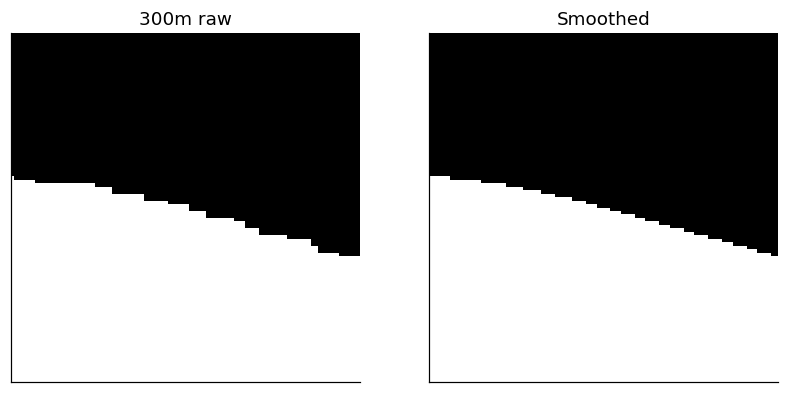

In [3]:
depth_grid_smooth = ndimage.gaussian_filter(depth_grid, sigma=BATHY_SMOOTH_M / RESOLUTION_M)
raw_shallow = depth_grid < FIXED_BOTTOM_MAX_DEPTH
smooth_shallow = depth_grid_smooth < FIXED_BOTTOM_MAX_DEPTH

diff_iy, diff_ix = np.nonzero(raw_shallow != smooth_shallow)
vc_iy, vc_ix = (vineyard_center[1] - y0) / RESOLUTION_M, (vineyard_center[0] - x0) / RESOLUTION_M
nearest = np.argmin((diff_iy - vc_iy) ** 2 + (diff_ix - vc_ix) ** 2)
cyi, cxi = int(diff_iy[nearest]), int(diff_ix[nearest])
half = int(15_000 / RESOLUTION_M)
sl = (slice(max(cyi - half, 0), cyi + half), slice(max(cxi - half, 0), cxi + half))

fig, axes = plt.subplots(1, 2, figsize=(9, 4.6))
axes[0].imshow(raw_shallow[sl], origin="lower", cmap="Greys")
axes[0].set_title("300m raw")
axes[1].imshow(smooth_shallow[sl], origin="lower", cmap="Greys")
axes[1].set_title("Smoothed")
for a in axes:
    a.set_xticks([]); a.set_yticks([])
plt.show()

### 3. Eligibility Mask & Outline

26,611 km2 eligible


/var/folders/1j/_3qt8y3s02n_m1mtt8pcvnh00000gr/T/ipykernel_50112/950576234.py:5: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  eligible = eligible_no_cluster & ~shapely_contains(cluster_shape, GX, GY)


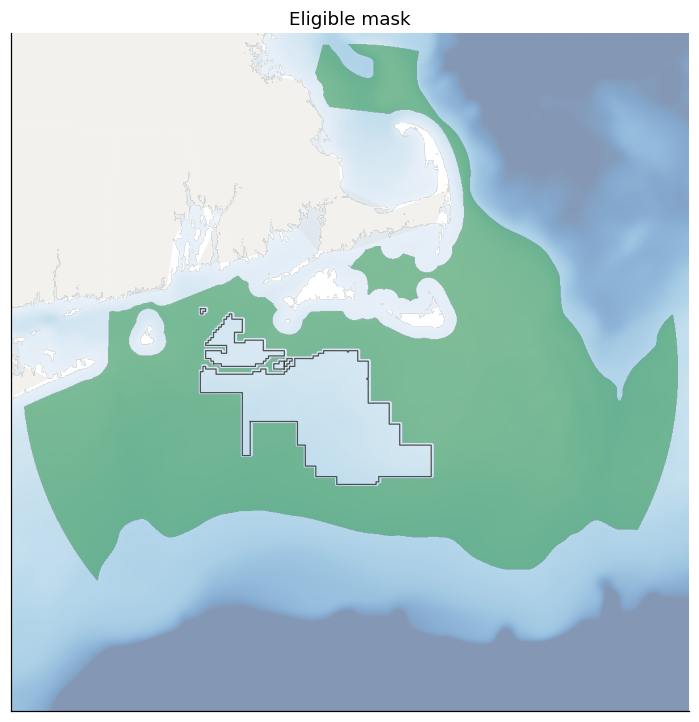

In [4]:
fed = (sla_side(GXf, GYf) == federal_sign).reshape(GX.shape)
within_radius = np.hypot(GX - vineyard_center[0], GY - vineyard_center[1]) < R
eligible_no_cluster = fed & smooth_shallow & within_radius
cluster_shape = unary_union(list(cluster.LEASE_TEMPLATES.values())).buffer(CLUSTER_BUFFER_M)
eligible = eligible_no_cluster & ~shapely_contains(cluster_shape, GX, GY)
eligible_area_km2 = eligible.sum() * (RESOLUTION_M / 1000.0) ** 2
print(f"{eligible_area_km2:,.0f} km2 eligible")

depth_grid_smooth_masked = np.ma.masked_where(on_land, depth_grid_smooth)
fig, ax = new_ax()
ax.set_xlim(EXTENT_KM[0], EXTENT_KM[1]); ax.set_ylim(EXTENT_KM[2], EXTENT_KM[3])
draw_land(ax)
ax.imshow(depth_grid_smooth_masked, origin="lower", extent=EXTENT_KM, cmap="Blues", vmax=200, alpha=0.5, zorder=1)
eligible_show = np.ma.masked_where(~eligible, eligible)
ax.imshow(eligible_show, origin="lower", extent=EXTENT_KM, cmap="Greens", vmin=0, vmax=1.4, alpha=0.55, zorder=2)
draw_cluster_outline(ax)
ax.set_title("Eligible mask")
plt.show()

### 4. Poisson Disk & Voronoi Mosaic

92 points (0.18s), r=[4.2,13.6]km


/var/folders/1j/_3qt8y3s02n_m1mtt8pcvnh00000gr/T/ipykernel_50112/138402658.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cat = cm.get_cmap("tab20")


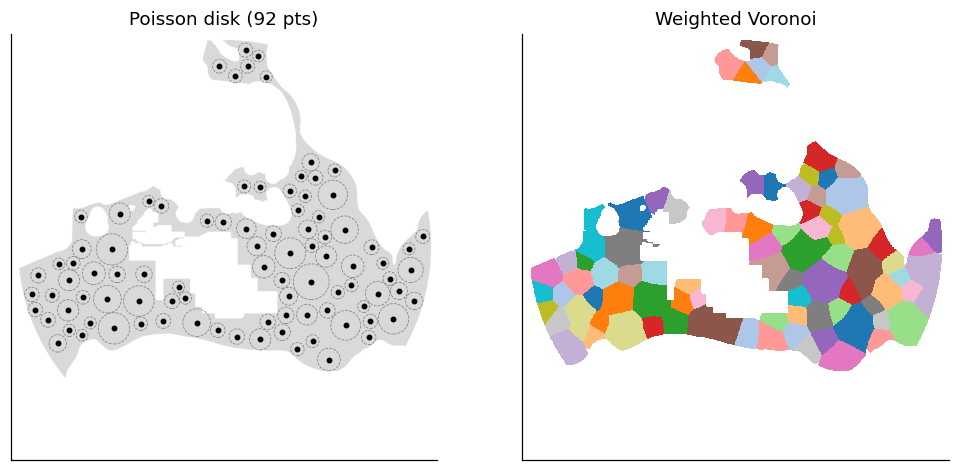

In [5]:
areas = np.array([p.area / 1e6 for p in cluster.LEASE_TEMPLATES.values()])
r_eq_km = np.sqrt(areas[areas >= FRAGMENT_AREA_KM2] / np.pi)
R_MIN_M, R_MAX_M = r_eq_km.min() * 1000.0, r_eq_km.max() * 1000.0

rng = np.random.default_rng(SEED)
t0 = time.time()
points, radii = mosaic.sample_variable_poisson_disk(eligible, x0, y0, RESOLUTION_M, R_MIN_M, R_MAX_M, rng)
t_sample = time.time() - t0
label_raw = mosaic.label_weighted_voronoi(eligible, x0, y0, RESOLUTION_M, points, radii)
print(f"{len(points)} points ({t_sample:.2f}s), r=[{R_MIN_M/1000:.1f},{R_MAX_M/1000:.1f}]km")

cmap_cat = cm.get_cmap("tab20")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.6))
ax = axes[0]
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.imshow(eligible, origin="lower", extent=EXTENT_KM, cmap="Greys", alpha=0.15)
for (px, py), r in zip(points, radii):
    ax.add_patch(Circle((px / 1000, py / 1000), r / 1000, fill=False, linestyle="--", linewidth=0.5, color="gray"))
ax.scatter(points[:, 0] / 1000, points[:, 1] / 1000, s=8, color="black", zorder=5)
ax.set_title(f"Poisson disk ({len(points)} pts)")

ax = axes[1]
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
shown = np.ma.masked_where(label_raw < 0, label_raw % 20)
cmap_bad = cmap_cat.copy(); cmap_bad.set_bad("white")
ax.imshow(shown, origin="lower", extent=EXTENT_KM, cmap=cmap_bad, interpolation="nearest")
ax.set_title("Weighted Voronoi")
plt.show()

In [6]:
label_buffered = mosaic.apply_gap_buffer(label_raw, buffer_cells=BUFFER_CELLS)
label_clean = mosaic.clean_labels(label_buffered)
polygons = mosaic.polygons_from_labels(label_clean, x0, y0, RESOLUTION_M)
print(f"{len(polygons)} parcels after gap buffer + cleanup")

92 parcels after gap buffer + cleanup


### 5. Full Coverage vs. N-Target Selection

target N=12 -> 12 drawn of 92 available


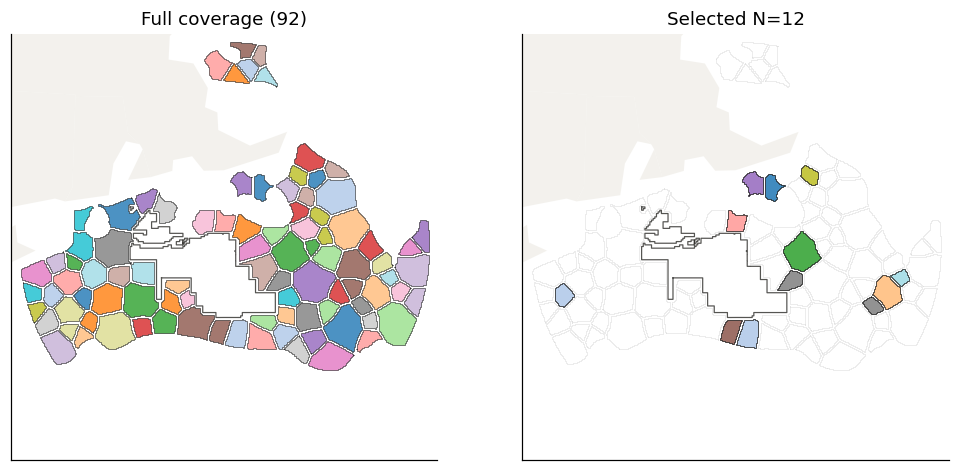

In [7]:
n_target = int(rng.integers(*settings.N_RANGE))
parcel_ids = list(polygons.keys())
n_draw = min(n_target, len(parcel_ids))
active_idx = set(rng.choice(parcel_ids, size=n_draw, replace=False).tolist())
print(f"target N={n_target} -> {len(active_idx)} drawn of {len(parcel_ids)} available")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.6))
ax = axes[0]
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
draw_land(ax)
ax.set_xlim(EXTENT_KM[0], EXTENT_KM[1]); ax.set_ylim(EXTENT_KM[2], EXTENT_KM[3])
for pid, poly in polygons.items():
    if poly.is_empty:
        continue
    bx, by = poly.exterior.xy
    ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color=cmap_cat(pid % 20), alpha=0.8, edgecolor="black", linewidth=0.4)
draw_cluster_outline(ax)
ax.set_title(f"Full coverage ({len(polygons)})")

ax = axes[1]
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
draw_land(ax)
ax.set_xlim(EXTENT_KM[0], EXTENT_KM[1]); ax.set_ylim(EXTENT_KM[2], EXTENT_KM[3])
for pid, poly in polygons.items():
    if poly.is_empty:
        continue
    bx, by = poly.exterior.xy
    if pid in active_idx:
        ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color=cmap_cat(pid % 20), alpha=0.85, edgecolor="black", linewidth=0.5)
    else:
        ax.plot(np.array(bx) / 1000, np.array(by) / 1000, color="lightgray", linewidth=0.4, alpha=0.7)
draw_cluster_outline(ax)
ax.set_title(f"Selected N={len(active_idx)}")
plt.show()

### 6. Temporal Distributions & Turbine Models

/var/folders/1j/_3qt8y3s02n_m1mtt8pcvnh00000gr/T/ipykernel_50112/1532459675.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.stackplot(years, share_matrix.T, labels=turbine_labels, colors=cm.get_cmap("viridis")(np.linspace(0.15, 0.9, len(turbines.NAMES))))


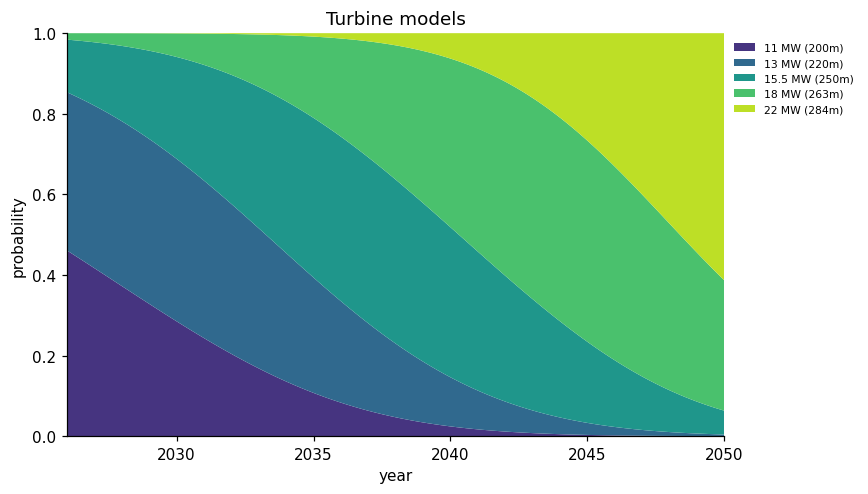

In [8]:
years = np.linspace(settings.YEAR_START, settings.YEAR_END, 200)
share_matrix = np.array([turbines.shares(y) for y in years])
turbine_labels = [f"{name} ({turbines.diameter(name):.0f}m)" for name in turbines.NAMES]

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.stackplot(years, share_matrix.T, labels=turbine_labels, colors=cm.get_cmap("viridis")(np.linspace(0.15, 0.9, len(turbines.NAMES))))
ax.set_xlim(years.min(), years.max())
ax.set_ylim(0, 1)
ax.set_xlabel("year")
ax.set_ylabel("probability")
ax.set_title("Turbine models")
ax.legend(loc="upper left", fontsize=7, ncol=1, frameon=False, bbox_to_anchor=(1.0, 1.0))
fig.tight_layout()
plt.show()

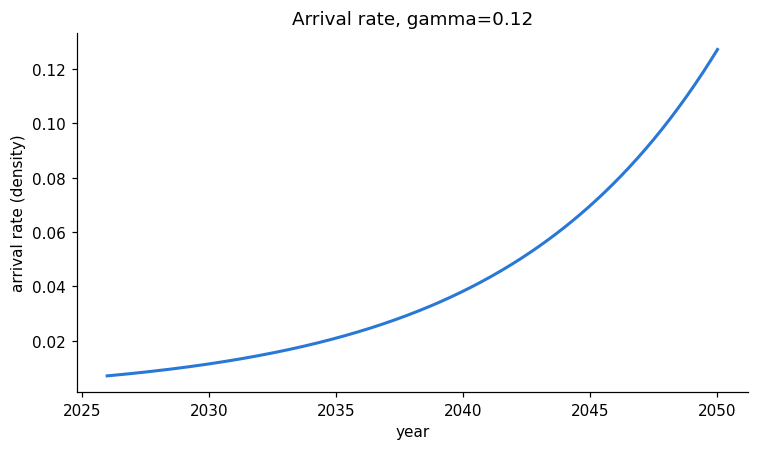

In [9]:
t = np.linspace(0, timeline.T, 300)
rate = settings.TIMELINE_GAMMA * np.exp(settings.TIMELINE_GAMMA * t) / (np.exp(settings.TIMELINE_GAMMA * timeline.T) - 1)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(settings.YEAR_START + t, rate, color="#2a78d6", linewidth=2)
ax.set_xlabel("year")
ax.set_ylabel("arrival rate (density)")
ax.set_title(f"Arrival rate, gamma={settings.TIMELINE_GAMMA}")
fig.tight_layout()
plt.show()

### 7. Timeline & Build Sequence: Cluster + Speculative

In [10]:
cluster_farms = cluster.generate_cluster(rng)

chosen_arr = np.array(sorted(active_idx))
n_draw = len(chosen_arr)
arrival_years_spec = timeline.draw_arrival_years(rng, n_draw)
order = rng.permutation(n_draw)

speculative_farms = []
for pid, idx in zip(chosen_arr, order):
    year = float(arrival_years_spec[idx])
    turbine = turbines.draw(rng, year)
    spacing_d = spacing.draw(rng)
    speculative_farms.append(dict(name=f"speculative_{int(pid)}", is_self=False, has_real_layout=False,
                                   arrival_year=year, turbine=turbine, spacing_d=spacing_d,
                                   polygon=polygons[int(pid)]))

events = []
for farm in cluster_farms:
    baseline = farm["has_real_layout"] or farm["is_self"]
    events.append(dict(label=farm["name"], polygon=cluster.LEASE_TEMPLATES[farm["name"]],
                        arrival_year=farm["arrival_year"], farm=farm, baseline=baseline))
for farm in speculative_farms:
    events.append(dict(label=farm["name"], polygon=farm["polygon"],
                        arrival_year=farm["arrival_year"], farm=farm, baseline=False))

numbered = sorted([e for e in events if not e["baseline"]], key=lambda e: e["arrival_year"])
for i, e in enumerate(numbered, start=1):
    e["seq"] = i
for e in events:
    if e["baseline"]:
        e["seq"] = None

norm_year = lambda y: (y - settings.YEAR_START) / (settings.YEAR_END - settings.YEAR_START)
cmap_time = cm.get_cmap("plasma")
COLOR_BASELINE = "#b0b0b0"
n_baseline = len(events) - len(numbered)
print(f"{n_baseline} already committed at {settings.YEAR_START}, {len(numbered)} arriving through {settings.YEAR_END}")

5 already committed at 2026, 20 arriving through 2050


/var/folders/1j/_3qt8y3s02n_m1mtt8pcvnh00000gr/T/ipykernel_50112/196485954.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_time = cm.get_cmap("plasma")


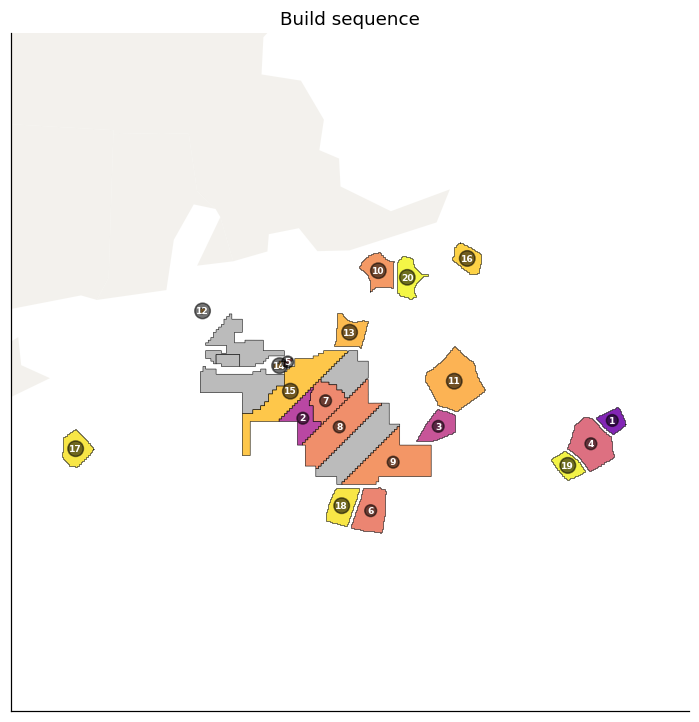

In [11]:
fig, ax = new_ax()
ax.set_xlim(EXTENT_KM[0], EXTENT_KM[1]); ax.set_ylim(EXTENT_KM[2], EXTENT_KM[3])
draw_land(ax)
for e in events:
    poly = e["polygon"]
    if poly.is_empty:
        continue
    bx, by = poly.exterior.xy
    if e["baseline"]:
        ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color=COLOR_BASELINE, alpha=0.85, edgecolor="black", linewidth=0.4)
    else:
        c = cmap_time(norm_year(e["arrival_year"]))
        ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color=c, alpha=0.85, edgecolor="black", linewidth=0.4)
        cx, cy = poly.centroid.x / 1000, poly.centroid.y / 1000
        ax.text(cx, cy, str(e["seq"]), ha="center", va="center", fontsize=6, fontweight="bold", color="white",
                bbox=dict(boxstyle="circle", facecolor="black", alpha=0.55, pad=0.15))
ax.set_title("Build sequence")
plt.show()

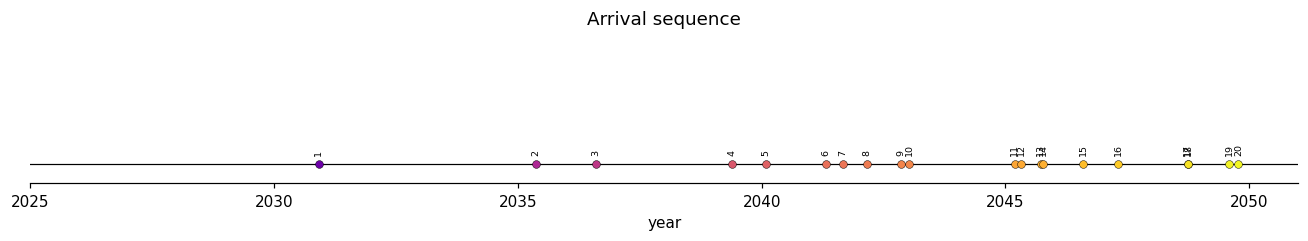

In [12]:
fig, ax = plt.subplots(figsize=(12, 2.3))
ax.axhline(0, color="black", linewidth=0.8, zorder=1)
for e in numbered:
    c = cmap_time(norm_year(e["arrival_year"]))
    ax.scatter([e["arrival_year"]], [0], color=c, s=26, zorder=3, edgecolor="black", linewidth=0.3)
    ax.text(e["arrival_year"], 0.12, str(e["seq"]), fontsize=6.2, ha="center", va="bottom", rotation=90)
ax.set_xlim(settings.YEAR_START - 1, settings.YEAR_END + 1)
ax.set_ylim(-0.25, 1.7)
ax.set_yticks([])
ax.set_xlabel("year")
ax.set_title("Arrival sequence")
for spine in ["top", "left", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

### 8. Layout Population & Spacing

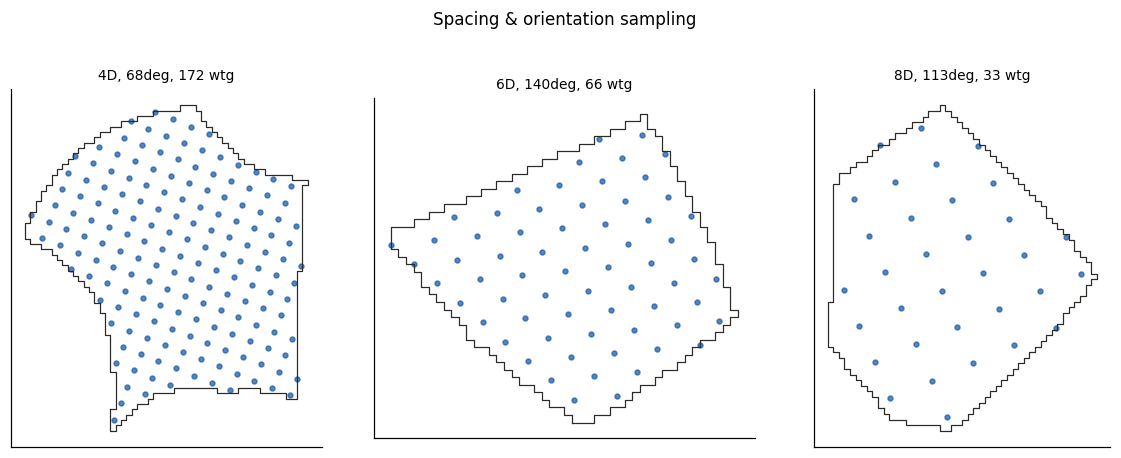

In [13]:
sample_events = [e for e in events if e["farm"]["name"].startswith("speculative_")]
sample_events = sorted(sample_events, key=lambda e: e["farm"]["spacing_d"])
step = max(1, len(sample_events) // 3)
sample_events = sample_events[::step][:3]

fig, axes = plt.subplots(1, 3, figsize=(11, 4.2))
for ax, e in zip(axes, sample_events):
    farm = e["farm"]
    poly = farm["polygon"]
    diameter = turbines.diameter(farm["turbine"])
    r_nominal = farm["spacing_d"] * diameter
    theta1 = float(rng.uniform(0, 180))
    pts, params = tiling.sample_aligned_grid(poly, rng, r_nominal, theta1_deg=theta1)
    bx, by = poly.exterior.xy
    ax.plot(np.array(bx) / 1000, np.array(by) / 1000, color=COLOR_LEASE, linewidth=0.8)
    if len(pts):
        ax.scatter(pts[:, 0] / 1000, pts[:, 1] / 1000, s=10, color="#1f5fa8", alpha=0.75)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{farm['spacing_d']}D, {theta1:.0f}deg, {len(pts)} wtg", fontsize=9)
fig.suptitle("Spacing & orientation sampling", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

3218 turbines placed across 25 farms


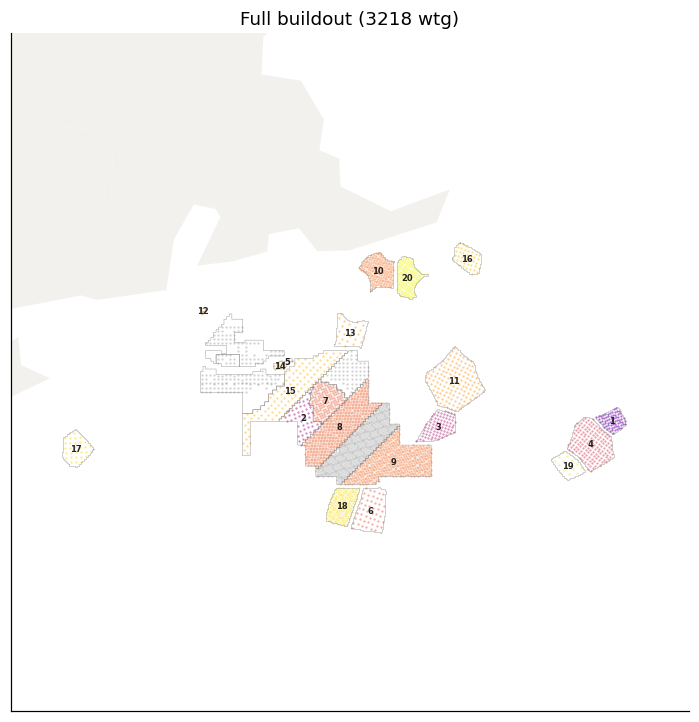

In [14]:
all_turbine_pts = []
for e in events:
    farm = e["farm"]
    c = COLOR_BASELINE if e["baseline"] else cmap_time(norm_year(e["arrival_year"]))
    if farm["has_real_layout"]:
        pts = np.column_stack([farm["x"], farm["y"]])
    else:
        diameter = turbines.diameter(farm["turbine"])
        r_nominal = farm["spacing_d"] * diameter
        theta1 = float(rng.uniform(0, 180))
        pts, _ = tiling.sample_aligned_grid(farm["polygon"], rng, r_nominal, theta1_deg=theta1)
    if len(pts):
        all_turbine_pts.append((pts, c))

total_wtg = sum(len(p) for p, _ in all_turbine_pts)
print(f"{total_wtg} turbines placed across {len(events)} farms")

fig, ax = new_ax()
ax.set_xlim(EXTENT_KM[0], EXTENT_KM[1]); ax.set_ylim(EXTENT_KM[2], EXTENT_KM[3])
draw_land(ax)
for e in events:
    poly = e["polygon"]
    if poly.is_empty:
        continue
    bx, by = poly.exterior.xy
    ax.plot(np.array(bx) / 1000, np.array(by) / 1000, color="gray", linewidth=0.35, alpha=0.7)
    if not e["baseline"]:
        cx, cy = poly.centroid.x / 1000, poly.centroid.y / 1000
        ax.text(cx, cy, str(e["seq"]), ha="center", va="center", fontsize=5.5, fontweight="bold", color="black", alpha=0.85)
for pts, c in all_turbine_pts:
    ax.scatter(pts[:, 0] / 1000, pts[:, 1] / 1000, s=2.2, color=c, alpha=0.55, linewidth=0)
ax.set_title(f"Full buildout ({total_wtg} wtg)")
plt.show()